In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from typing import Annotated, TypedDict, List, Dict, Any, Optional, Literal
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from IPython.display import Image, display
from operator import add
import uuid

from db_con import get_user_hobbies, get_user_location

In [2]:
load_dotenv(override=True)

True

In [3]:
StressAnswer = Literal[
    "Never",
    "Almost Never",
    "Sometimes",
    "Fairly Often",
    "Very Often"
]

In [4]:
StressLevels = Literal[
    "Low Stress",
    "Moderate Stress", 
    "High Stress", 
    "No Stress"]

In [5]:
class SearchResultItem(TypedDict):
    place_type: str
    title: str
    content: str
    url: str

In [6]:
QUESTIONS = [
"In the last month, how often have you been upset because of something that happened unexpectedly?"
]

In [7]:
class State(TypedDict):
    user_id: str
    messages: Annotated[List[Any], add_messages]
    topic_counter: int
    interact_with_user: bool
    temporal_answer: Optional[StressAnswer]
    actual_answers: Annotated[List[StressAnswer], add]
    stress_level: Optional[StressLevels]
    recommendations: Optional[str]
    complete_test:bool
    search_results: Optional[List[SearchResultItem]]


In [8]:
class PsychiatristOutput(BaseModel):

    response: str = Field(
        description="Message to send to the user."
    )

    temporal_answer: Optional[StressAnswer] = Field(
        default=None,
        description="Final answer to the stress question if determined."
    )

    interact_with_user: bool = Field(
        description="Whether psychiatrist should continue interacting."
    )

In [9]:
psychiatrist_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

psychiatrist_llm_with_output = psychiatrist_llm.with_structured_output(PsychiatristOutput)

In [10]:
def psychiatrist(state: State) -> State:

    base_system_message = f"""
You are a professional psychiatrist conducting a stress evaluation interview.

Your goal is to determine the user's answer to the following question:

{QUESTIONS[state["topic_counter"]]}

Allowed answers:
Never
Almost Never
Sometimes
Fairly Often
Very Often

Instructions:
- Have a natural conversation with the user.
- Ask follow-up questions if the answer is unclear.
- Don't give suggested answers to the user.
- Only produce a temporal_answer if there is enough evidence from the conversation.
- If unsure, set temporal_answer to null and continue the conversation.

Rules:
If answer is clear:
    temporal_answer = one of allowed answers
    interact_with_user = false

If not answer is clear:
    temporal_answer = null
    interact_with_user = true

Conversation Rules:
- Only respond to stress-related or wellness-related queries. (consider message history to identify relevance if needed)
- If the user asks something unrelated, respond with:
  "I’m here to help only with stress management and mental wellness."
- Keep the conversation natural, supportive, and empathetic.
- Keep responses clear and concise (avoid long paragraphs).

"""


    messages = (
        [SystemMessage(content=base_system_message)]
        + state["messages"]
    )

    psychiatrist_response = psychiatrist_llm_with_output.invoke(messages)

    return {
        "messages": [AIMessage(content=psychiatrist_response.response)],
        "temporal_answer": psychiatrist_response.temporal_answer,
        "interact_with_user": psychiatrist_response.interact_with_user
    }

In [11]:
def store_answer(state: State) -> State:

    return {
        "actual_answers": [state["temporal_answer"]],
        "topic_counter": state["topic_counter"] + 1,
        "temporal_answer": None
    }

In [12]:
score_map = {
    "Never":0,
    "Almost Never":1,
    "Sometimes":2,
    "Fairly Often":3,
    "Very Often":4
}

def calculate_stress(state: State):

    score = sum(score_map[a] for a in state["actual_answers"])

    if score <= 5:
        level = "No Stress"
    elif score <= 13:
        level = "Low Stress"
    elif score <= 26:
        level = "Moderate Stress"        
    else:
        level = "High Stress"

    return {"stress_level": level,
            "messages":[AIMessage(content=f"Your stress level is {level} with a score of {score}.")],
            "complete_test": True
            }

In [13]:
def retrieval_node(state: State):
    stress_level = state["stress_level"]
    from retrieval import fetch_context

    docs = fetch_context(f"recommendation for {stress_level}")
    context = "\n\n".join(doc.page_content for doc in docs)    

    return {
        "recommendations": context
    }

In [14]:
import os
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))


def tavily_search(query: str):
    response = tavily_client.search(
        query=query,
        search_depth="basic",
        max_results=5
    )

    results = []

    for r in response.get("results", []):
        results.append({
            "title": r.get("title"),
            "url": r.get("url"),
            "content": r.get("content")
        })

    return results

In [15]:
# print(tavily_search("psychiatrist in colombo"))

In [16]:
# from langchain.tools import tool

# @tool
# def search_places(query: str) -> list:
#     """
#     Search for places using Tavily.

#     Input:
#         query: search string like "best beaches near Colombo"

#     Output:
#         list of results with title, url, content
#     """
#     return tavily_search(query)

In [17]:
# if __name__ == "__main__":
#     results = search_places.invoke({
#         "query": "dancing classes near Colombo"
#     })

#     for r in results:
#         print("\n---")
#         print("Title:", r["content"])
#         print("URL:", r["url"])

In [18]:
class SearchQueryItem(BaseModel):
    query: str = Field(
        description="Type of place user should visit (e.g., beach, park, psychiatrist)"
    )

class QueryBuilderOutput(BaseModel):
    queries: List[SearchQueryItem]

In [19]:
from langchain_openai import ChatOpenAI

query_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

query_llm_structured = query_llm.with_structured_output(QueryBuilderOutput)

In [20]:
def online_search(state: dict) -> dict:
    recommendations = state["recommendations"]
    location= get_user_location(state["user_id"])

    system_prompt = """
You extract ONLY place-based actions from given recommendations only.

Goal:
Return types of places the user should visit.

STRICT RULES:

1. ONLY include recommendations that require going to a place

2. IGNORE completely:
- food (eat, drink)
- breathing exercises
- sleep
- talking to friends
- indoor activities

3. Extract ONLY place types (NOT full sentences)

Allowed outputs:
- beach
- park
- waterfall
- jungle
- psychiatrist
- therapist
- nature place
- dancing class
- gym
- yoga
- music concert

4. Normalize vague phrases:
- "go outside" → park or nature place
- "get professional support" → psychiatrist

5. Output must be SIMPLE words/phrases:
❌ "best beaches near city"
❌ "visit a park nearby"
✅ "beach"
✅ "park"

6. Remove duplicates

7. If nothing matches → return empty list
"""

    response = query_llm_structured.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=recommendations)
    ])

    queries = list({item.query.lower() for item in response.queries})

    if queries is None:
        return {
            "search_results": []
        }

    all_results = []

    for place in queries:
        query = f"best {place}s near {location}"

        response = tavily_client.search(
            query=query,
            search_depth="basic",
            max_results=1
        )

        for r in response.get("results", []):
            all_results.append({
                "place_type": place,
                "title": r.get("title"),
                "content": r.get("content"),
                "url": r.get("url")
            })



    return {
        "search_results": all_results
    }

In [21]:
# print(online_search({
#     "recommendations": "## Recommendation\nStress_Level: LOW  \nTitle: Eat Nuts and Seeds\n\nEat almonds, cashews, pumpkin seeds, and sunflower seeds.  \nA small handful per day is enough.\n\n\n## Recommendation\nStress_Level: LOW  \nTitle: Limit Certain Foods\n\nReduce coffee because too much caffeine increases heart rate and anxiety.  \nReduce high sugar snacks.  \nAvoid high salt and unhealthy fats.  \nAvoid heavy meals before sleep.\n\n\n---\n\n## Recommendation\nStress_Level: MODERATE  \nTitle: Breathing and Relaxation\n\n## Recommendation\nStress_Level: LOW  \nTitle: Eat Dark Chocolate\n\nDark chocolate can help reduce stress when used in a mindful, small-portion way.\n\n\n## Recommendation\nStress_Level: LOW  \nTitle: Deep Breathing\n\nInhale for 4 seconds.  \nExhale for 6 seconds.  \nRepeat 10 times.\n\n\n## Recommendation\nStress_Level: LOW  \nTitle: Step Outside\n\nStep outside and enjoy the environment.  \nGo to a nearby small jungle, beach, or waterfall.  \nGet sunlight.  \nFeel the fresh air.  \nNotice your surroundings.\n\n## Recommendation\nStress_Level: LOW  \nTitle: Talk with a Friend\n\nTalk to someone safe for a few minutes.  \nSharing reduces even small amounts of stress.\n\n\n## Recommendation\nStress_Level: LOW  \nTitle: Dance\n\nStart with gentle swaying.  \nMove arms and shoulders.  \nStep to the side.  \nSmile or laugh naturally.\n\n\n## Recommendation\nStress_Level: LOW  \nTitle: Short Nap\n\nTake 20–30 minutes of sleep now.  \nExtend nightly sleep to 7–8 hours every day..",
#     "user_id": "6RuThcCebLMWBdAUxSrhKZLEHei2"
# }))

In [22]:
class RecommendationOutput(BaseModel):

    response: str = Field(
        description="Message to send to the user or recommendations based on stress level and search results."
    )
    
    interact_with_user: bool = Field(
        description="Whether recommendations giver should continue interacting with user."
    )

In [23]:
recommendations_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

recommendations_llm_with_output = recommendations_llm.with_structured_output(RecommendationOutput)

In [24]:
def recommendation(state: State) -> State:

    hobbies = get_user_hobbies(state["user_id"])
    location=get_user_location(state["user_id"])
    hobbies_str = ", ".join(hobbies)
    search_results_str = "\n\n".join(
    f"Place: {r['title']}\n"
    f"Type: {r['place_type']}\n"
    f"Description: {(r.get('content') or '')[:100]}...\n"
    f"Link: {r['url']}"
    for r in state.get("search_results", [])
)
    
    
    print(search_results_str)
    
    base_system_message = f"""
    You are a supportive mental wellness assistant having a natural conversation with the user.

    Context:
    - User stress level : {state["stress_level"]}
    - Retrieved stress-management recommendations from the knowledge base: {state["recommendations"]}
    - User hobbies: {hobbies_str}
    - recommended places: {search_results_str}
    
    Instructions:
    - Politely inform the user about the stress level(exactly given) determined from analyzing their responses.
    - Provide helpful recommendations to reduce stress using the retrieved recommendations. 
    - mandatory: Add "recommended places" to the response if there are "recommended places" in the context.
    - If possible, relate the suggestions to the user's hobbies.
    - Answer any related questions the user asks and continue the conversation naturally.
    - Be supportive, empathetic, and keep responses clear and concise.
    - If the stress level is **"No Stress"**, politely inform the user that they currently do not show signs of stress and no specific recommendations are necessary, but encourage them to maintain healthy habits.

    Conversation Rules:
    - Only respond to stress-related or wellness-related queries.
    - If the user asks something unrelated, respond with:
      "I’m here to help only with stress management and mental wellness. How can I assist you with that?"
    - Keep the conversation natural, supportive, and empathetic.
    - Keep responses clear and concise (avoid long paragraphs).
    """
    messages = (
        [SystemMessage(content=base_system_message)]
        + state["messages"]
    )

    recommendation_response = recommendations_llm_with_output.invoke(messages)

    return {
        "messages": [AIMessage(content=recommendation_response.response)],
        "interact_with_user": recommendation_response.interact_with_user
    }

In [25]:
def start_node_router(state: State):
    if state["complete_test"]:
        return "recommendation"
    else:
        return "psychiatrist"

In [26]:
def after_recommendation_router(state: State):

    if state["interact_with_user"]:
        return "END"

    return "END"

In [27]:
def psychiatrist_router(state: State):

    if state["interact_with_user"]:
        return "END"

    return "store_answer"

In [28]:
def after_store_router(state: State):

    if state.get("topic_counter", 0) >= len(QUESTIONS):
        return "calculate_stress"

    return "psychiatrist"

In [29]:
builder = StateGraph(State)

builder.add_node("psychiatrist", psychiatrist)
builder.add_node("store_answer", store_answer)
builder.add_node("calculate_stress", calculate_stress)
builder.add_node("retrieval", retrieval_node)
builder.add_node("search", online_search)
builder.add_node("recommendation", recommendation)

builder.add_conditional_edges(
    START,
    start_node_router,
    {"psychiatrist": "psychiatrist",
     "recommendation": "recommendation"}
)
builder.add_conditional_edges(
    "psychiatrist",
    psychiatrist_router,
    {
        "END": END,
        "store_answer": "store_answer"
    }
)
builder.add_conditional_edges(
    "store_answer",
    after_store_router,
    {
        "psychiatrist": "psychiatrist",
        "calculate_stress": "calculate_stress"
    }
)
builder.add_conditional_edges(
    "recommendation",
    after_recommendation_router,
    {
        "END": END,
        "END": END
    }
)

builder.add_edge("calculate_stress", "retrieval")
builder.add_edge("retrieval", "search")
builder.add_edge("search", "recommendation")
builder.add_edge("recommendation", END)
memory = MemorySaver()

graph = builder.compile(checkpointer=memory)

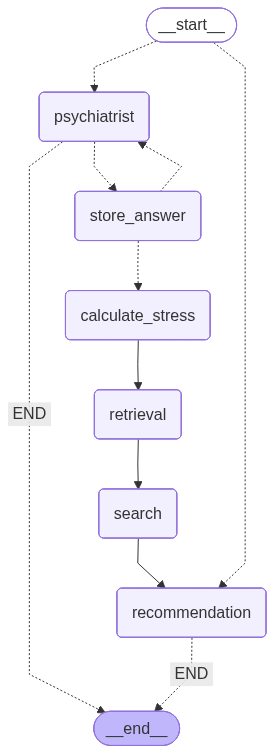

In [30]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
thread_config = {
    "configurable": {
        "thread_id": uuid.uuid4()
    }
}

In [41]:
result = graph.invoke(
    {
        "messages": [HumanMessage(content="who is prime minister in sri lanka?")],
        "user_id":"6RuThcCebLMWBdAUxSrhKZLEHei2",
        "topic_counter": 0,
        "actual_answers": [],
        "temporal_answer": None,
        "interact_with_user": True,
        "stress_level": None,
        "recommendations": None,
        "complete_test": False
    },
    config=thread_config
)
result

{'user_id': '6RuThcCebLMWBdAUxSrhKZLEHei2',
 'messages': [HumanMessage(content='who is prime minister in sri lanka?', additional_kwargs={}, response_metadata={}, id='7c142f7e-5b39-4f25-b06f-65bb5b4764a0'),
  AIMessage(content='I’m here to help only with stress management and mental wellness.', additional_kwargs={}, response_metadata={}, id='62531304-2fae-4a90-ba23-74a0fb72a103', tool_calls=[], invalid_tool_calls=[])],
 'topic_counter': 0,
 'interact_with_user': True,
 'temporal_answer': None,
 'actual_answers': [],
 'stress_level': None,
 'recommendations': None,
 'complete_test': False}

In [42]:
result = graph.invoke(
    {
        "messages": [HumanMessage(content="i want to measure my stress?")],
    },
    config=thread_config
)
result

{'user_id': '6RuThcCebLMWBdAUxSrhKZLEHei2',
 'messages': [HumanMessage(content='who is prime minister in sri lanka?', additional_kwargs={}, response_metadata={}, id='7c142f7e-5b39-4f25-b06f-65bb5b4764a0'),
  AIMessage(content='I’m here to help only with stress management and mental wellness.', additional_kwargs={}, response_metadata={}, id='62531304-2fae-4a90-ba23-74a0fb72a103', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='i want to measure my stress?', additional_kwargs={}, response_metadata={}, id='37bf2858-4feb-4ce6-accd-b6492584970e'),
  AIMessage(content="That's a great step towards understanding your mental wellness. To start, I’d like to ask you a specific question: In the last month, how often have you been upset because of something that happened unexpectedly?", additional_kwargs={}, response_metadata={}, id='3f344396-16be-4552-953d-52524ef6e1b0', tool_calls=[], invalid_tool_calls=[])],
 'topic_counter': 0,
 'interact_with_user': True,
 'temporal_answer': Non

In [39]:
print(result["messages"][-1].content)

Since your stress level is currently at No Stress, there are no specific recommendations necessary. However, here are some general tips to maintain your well-being:

1. **Eat Nuts and Seeds**: Incorporate a small handful of almonds, cashews, or pumpkin seeds into your daily diet for their health benefits.

2. **Limit Certain Foods**: Try to reduce caffeine intake, high sugar snacks, and heavy meals before sleep to keep your energy levels stable.

3. **Enjoy Dark Chocolate**: A small portion of dark chocolate can be a delightful treat that may help in reducing stress.

4. **Practice Deep Breathing**: Inhale for 4 seconds, exhale for 6 seconds, and repeat this 10 times to help relax your mind.

5. **Step Outside**: Spend some time outdoors, whether it's in a park, beach, or near a waterfall, to enjoy the fresh air and nature.

Engaging in your hobbies like reading, photography, or gardening can also be great ways to maintain your mental wellness. If you have any specific questions or nee